# Exploratory Data Analysis (EDA)

## Table of Contents
1. [Dataset Overview](#dataset-overview)
2. [Handling Missing Values](#handling-missing-values)
3. [Feature Distributions](#feature-distributions)
4. [Possible Biases](#possible-biases)
5. [Correlations](#correlations)


. [Correlations](#correlations)


In [6]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import matplotlib.pyplot as plt
from PIL import Image
from IPython.display import display, HTML

## Dataset Overview


- **Source:** Self-recorded rowing videos (2 female individuals), processed using MediaPipe Pose Landmarker  
- **Samples:** 21,791 frames (256×256 px, skeleton on a black background)  --> reduced to 7265 frames for better performance
- **Features:**  
  - 256×256×3 = 196,608 pixel values per frame (for CNNs)  
  - 33 landmarks × 3 coordinates = 99 features (for tabular models)  
- **Labels:** Binary — GOOD vs. BAD

### 1. Overview: Number of Videos, Strokes, Frames per Second etc.

In [ ]:
df_documentation = pd.read_csv("dataset_documentation_combined.csv")

# Add a row for totals and averages
total_duration = round(df_documentation["duration_s"].sum(), 1)
total_OG_fps      = round(df_documentation["OG_fps"].mean(), 1)
total_reduced_fps = round(df_documentation["reduced_fps"].mean(), 1)
total_og      = df_documentation["OG_total_frames"].sum()
total_reduced = df_documentation["reduced_total_frames"].sum()
total_strokes = df_documentation["n_strokes"].sum()
total_stroke_rate = round(df_documentation["stroke_rate_spm"].mean(), 1)

df_documentation.loc[len(df_documentation)] = [
    "Gesamt", total_duration, total_OG_fps, total_reduced_fps, total_og, total_reduced, total_strokes, total_stroke_rate
]
print("Overview of number of Videos and their characteristics:")
display(df_documentation)

print("------------------------------")

# Display total number of good strokes across all videos
total_good_strokes = df_documentation[df_documentation["video_name"].str.contains("GOOD")]["n_strokes"].sum()
display(HTML(
    f'Total <span style="color:green"><b>number</b></span> of <span style="color:green"><b>good strokes</b></span> across all videos: <span style="color:green"><b>{total_good_strokes}</b></span>'
))

# Display total number of bad strokes across all videos
total_bad_strokes = df_documentation[df_documentation["video_name"].str.contains("BAD")]["n_strokes"].sum()
display(HTML(
    f'Total <span style="color:red"><b>number</b></span> of <span style="color:red"><b>bad strokes</b></span> across all videos: <span style="color:red"><b>{total_bad_strokes}</b></span>'
))

# Display total number of strokes across all videos
total_strokes = df_documentation[df_documentation["video_name"] != "Gesamt"]["n_strokes"].sum()
display(HTML(
    f'Total number of all quality strokes across all videos: <b><u>{total_strokes}</u></b>'
))

Overview of number of Videos and their characteristics:


,video_name,duration_s,OG_fps,reduced_fps,OG_total_frames,reduced_total_frames,n_strokes,stroke_rate_spm
0,cla-BAD,50.6,30.0,10.0,1518,506,21,24.9
1,cla-GOOD-fast,209.3,30.0,10.0,6280,2094,88,25.2
2,cla-GOOD-slow,189.9,30.0,10.0,5698,1900,68,21.5
3,mar-GOOD-fast,140.6,30.0,10.0,4217,1406,62,26.5
4,mar-GOOD-slow,135.9,30.0,10.0,4076,1359,51,22.5
5,Gesamt,726.3,30.0,10.0,21789,7265,290,24.1


------------------------------


### 2. Overview: Landmark Data
- After processing the OG_Videos with MediaPipe, I extracted all landmark coordinates into a CSV at 10 frames per second
- Using all 33 Landmarks

In [8]:
# Load the data
# Replace 'your_dataset.csv' with the path to your actual dataset
landmarks_dir = Path("/Users/clarabrilke/ML projects/ML-project/1_DatasetCharacteristics/landmarks")
df = pd.read_csv(landmarks_dir / "landmarks_all_10fps.csv")

# Number of samples
num_samples = df.shape[0]

# Number of features
num_features = df.shape[1]

# Display these dataset characteristics
print(f"Number of samples: {num_samples}")
print(f"Number of features: {num_features}")

# Display the first few rows of the dataframe to show the structure
print("Example data:")
display(df.head())

print("---------------------------------")

# Display total number of frames across all videos
mask = df_documentation["video_name"] != "Gesamt"
total_frames = df_documentation.loc[mask, "OG_total_frames"].sum()
print(f"Total number of frames across all videos (before reduction to 10 fps): {total_frames}")
total_frames = df_documentation.loc[mask, "reduced_total_frames"].sum()
print(f"Total number of frames across all videos (after reduction to 10 fps): {total_frames}")

Number of samples: 7265
Number of features: 101
Example data:


,nose_x,nose_y,nose_z,left_eye_inner_x,left_eye_inner_y,left_eye_inner_z,left_eye_x,left_eye_y,left_eye_z,left_eye_outer_x,...,right_heel_y,right_heel_z,left_foot_index_x,left_foot_index_y,left_foot_index_z,right_foot_index_x,right_foot_index_y,right_foot_index_z,Good Stroke,Bad Stroke
0,0.615746,0.210794,-0.190708,0.626361,0.193198,-0.197250,0.630794,0.192846,-0.197299,0.635198,...,0.725613,0.058263,0.482900,0.720617,-0.229427,0.469207,0.704439,0.013369,0,1
1,0.630679,0.208123,-0.143015,0.640137,0.192183,-0.145637,0.644246,0.192184,-0.145651,0.649214,...,0.734995,-0.020031,0.471363,0.723228,-0.440409,0.460441,0.702628,-0.076609,0,1
2,0.651808,0.208442,-0.131141,0.662814,0.192747,-0.128481,0.667506,0.192836,-0.128477,0.672253,...,0.738925,-0.086889,0.473155,0.730101,-0.494903,0.456453,0.695856,-0.145698,0,1
3,0.671585,0.208336,-0.175947,0.682319,0.193612,-0.171649,0.686344,0.193936,-0.171657,0.690529,...,0.745891,-0.078262,0.486114,0.725720,-0.451390,0.458284,0.691605,-0.138502,0,1
4,0.689054,0.211714,-0.162716,0.699243,0.196599,-0.159009,0.703672,0.196809,-0.159017,0.708004,...,0.736228,-0.070282,0.496336,0.722220,-0.463061,0.463322,0.688898,-0.132418,0,1


---------------------------------
Total number of frames across all videos (before reduction to 10 fps): 21789
Total number of frames across all videos (after reduction to 10 fps): 7265


## Handling Missing Values

❌ No missing values

## Feature Distributions

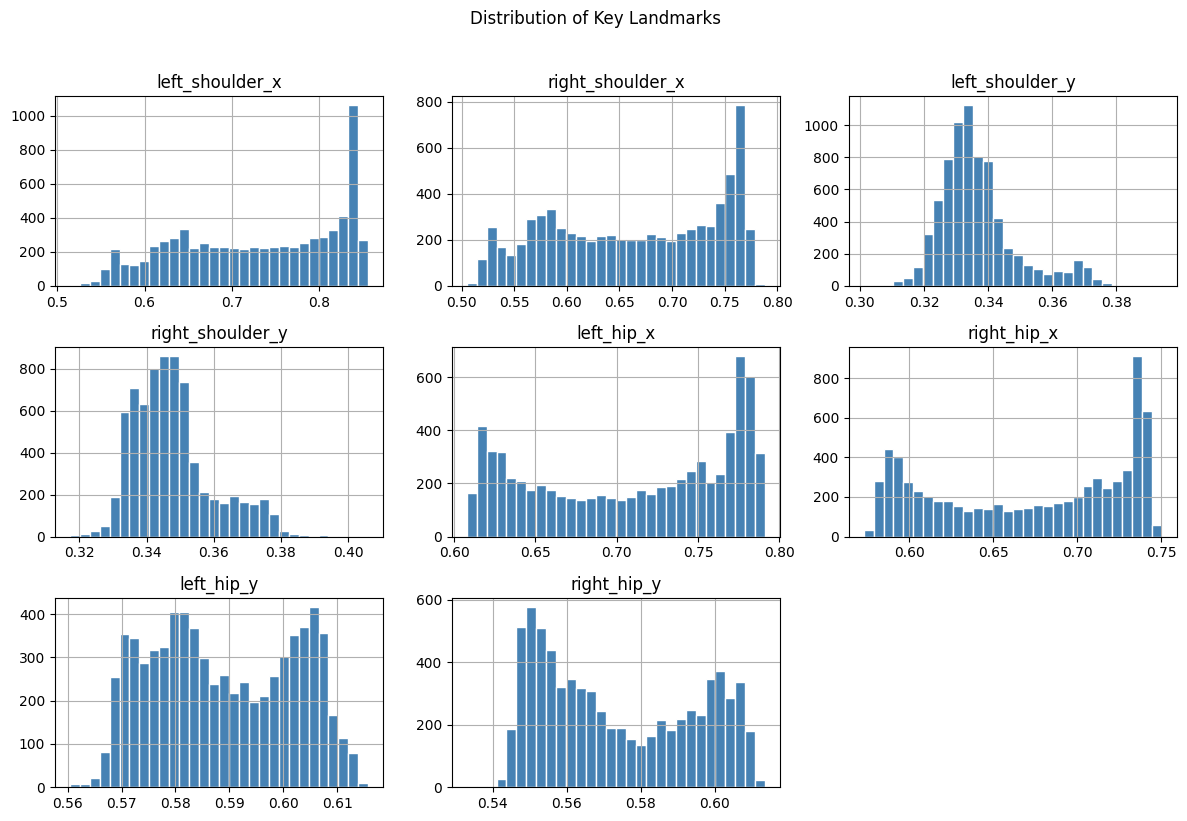

In [13]:
cols = [
    "left_shoulder_x", "right_shoulder_x",
    "left_shoulder_y", "right_shoulder_y",
    "left_hip_x",      "right_hip_x",
    "left_hip_y",      "right_hip_y",
]

df[cols].hist(figsize=(12, 8), bins=30, color="steelblue", edgecolor="white")
plt.suptitle("Distribution of Key Landmarks", y=1.02)
plt.tight_layout()
plt.show()


### Interpretation: Distribution of Key Landmarks

All values are normalized (0–1), where x = horizontal (left→right) and y = vertical (top→bottom).

**Shoulders (y-coordinates)** — `left_shoulder_y` ~0.33, `right_shoulder_y` ~0.34:
Narrow, peaked distribution → shoulders remain vertically stable throughout the rowing stroke,
which makes sense as rowing is primarily a horizontal movement.

**Shoulders (x-coordinates)** — wide distribution with a spike at the edge:
Shoulders move strongly in the horizontal direction, reflecting the forward and backward swing of the upper body.
The spike at the far end represents the **Finish position**: although rowers move continuously,
the shoulders briefly slow down at the back because the arms still need to be pulled in —
resulting in more frames captured at that position.

**Hips (x-coordinates)** — `left_hip_x` and `right_hip_x` both bimodal (two peaks):
Two distinct clusters suggest two typical positions — likely **Catch** (body forward, blade in water)
and **Finish** (body back, blade out of water). This indicates that MediaPipe captures the rowing cycle well.

**Hips (y-coordinates)** — flat distribution:
The hips show more vertical variation than the shoulders,
reflecting the slight forward and backward tilt of the upper body during the stroke.


**Conclusion:** The distributions are plausible and reflect the biomechanics of rowing.


## Biases

### 1. Label Imbalance

The dataset is heavily imbalanced:

Good frames: 6759 (93.0%)
Bad frames:  506 (7.0%)


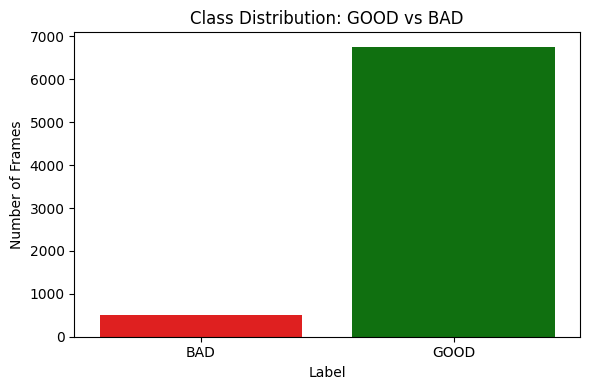

In [14]:
df["Label"] = df["Good Stroke"].map({1: "GOOD", 0: "BAD"})

good_frames = df[df["Label"] == "GOOD"].shape[0]
bad_frames  = df[df["Label"] == "BAD"].shape[0]
total       = len(df)

print(f"Good frames: {good_frames} ({good_frames/total*100:.1f}%)")
print(f"Bad frames:  {bad_frames} ({bad_frames/total*100:.1f}%)")


plt.figure(figsize=(6, 4))
sns.countplot(x="Label", data=df, hue="Label", palette={"GOOD": "green", "BAD": "red"}, legend=False)
plt.title("Class Distribution: GOOD vs BAD")
plt.xlabel("Label")
plt.ylabel("Number of Frames")
plt.tight_layout()
plt.show()



This imbalance may bias the model toward predicting **good technique** more frequently, since the majority of training examples belong to the *GOOD* class.

To address this issue, additional data representing **bad rowing strokes** will be generated in future iterations of the dataset.

### 2. Dataset Characteristics and Limitations

At the current stage, the dataset is intentionally designed to be **homogeneous**.

Only **two female participants** were recorded in order to establish an initial baseline model capable of learning fundamental rowing movement patterns and distinguishing between **correct** and **incorrect** technique.

---

#### Advantages of the Controlled Setup

This simplified setup offers several benefits during the early development phase:

- Reduced variability in:
  - body proportions
  - movement dynamics
  - rowing style
- Easier identification of systematic model errors
- More stable training conditions for initial experiments
- Faster validation of preprocessing and feature extraction pipelines

By limiting diversity at the beginning, the primary focus remains on validating whether the selected architectures and extracted features can learn meaningful motion representations at all.

---

#### Current Limitations

Despite these advantages, the dataset also introduces several important limitations:

- The model may overfit to the specific body shapes and movement patterns of the recorded participants
- Generalization to other athletes, genders, body types, and rowing styles is currently limited
- The dataset does not yet reflect the variability encountered in real-world rowing scenarios

---

#### Future Work

Future extensions of the dataset will therefore include:

- Recordings of participants with more diverse physical characteristics  
  *(partially already generated)*
- Increased variation in:
  - rowing intensity
  - posture
  - camera perspectives

---

### Summary

The current dataset should therefore be considered a **proof-of-concept foundation** for developing and validating the overall machine learning pipeline before scaling toward a more generalized and representative dataset.

## Correlations

[Explore correlations between features and the target variable, as well as among features themselves.]


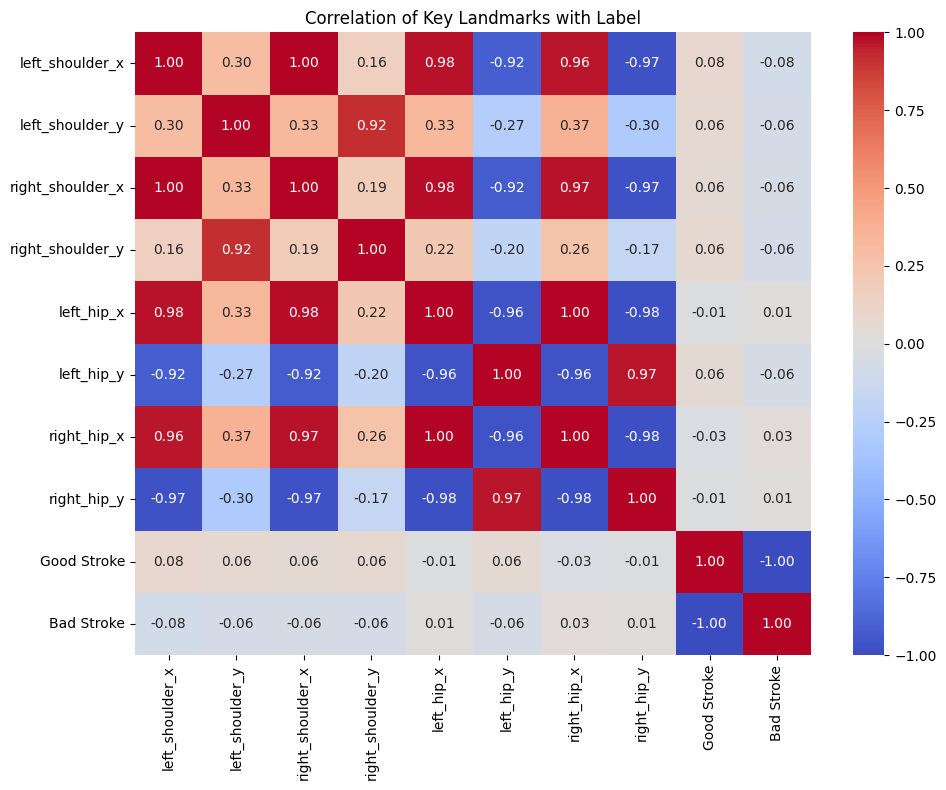

In [15]:
# Example: Plotting a heatmap to show feature correlations
key_cols = [
    "left_shoulder_x", "left_shoulder_y",
    "right_shoulder_x", "right_shoulder_y",
    "left_hip_x", "left_hip_y",
    "right_hip_x", "right_hip_y",
    "Good Stroke", "Bad Stroke"
]

correlation_matrix = df[key_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation of Key Landmarks with Label")
plt.tight_layout()
plt.show()



### Correlation Heatmap: Key Landmarks vs. Labels

**Most important finding — bottom right (Good Stroke / Bad Stroke):**
All correlations with the labels are nearly **0** (~0.08 max). This means that the absolute position of shoulders and hips alone barely distinguishes GOOD from BAD strokes. The model will likely need more complex patterns — e.g., movement sequences, additional landmarks, or temporal features.

**Correlations among landmarks:**

- `left_shoulder_x` ↔ `right_shoulder_x` = **1.00** → both shoulders always move together horizontally
- `left_hip_x` ↔ `right_hip_x` = **1.00** → both hips as well
- `shoulder_x` ↔ `hip_x` = **~0.98** → shoulders and hips move in sync horizontally — the entire upper body swings as one unit
- `x` ↔ `y` = **strongly negative (~-0.92 to -0.97)** → as the body moves right (x increases), it simultaneously moves upward in the frame (y decreases), reflecting the forward lean in the rowing stroke

**Conclusion:** The landmarks are highly correlated with each other (the body moves as a whole), but they carry little information about whether a stroke is good or bad.
